# Search-03b — Bases de données de motifs (Pattern Databases) pour le 15-puzzle

> **Partie 3 — Recherche avancée.** Ce notebook ouvre la Partie 3 : techniques de
> recherche heuristique *avancées*, au-delà des fondations de la
> [Partie 1](../Part1-Foundations/Search-03-Informed.ipynb) (A\*, IDA\*, heuristiques
> admissibles), sans relever ni de la programmation par contraintes
> ([Partie 2](../Part2-CSP/CSP-1-Fundamentals.ipynb)) ni des métaheuristiques
> ([Partie 4](../Part4-Metaheuristics/README.md)).

## 1. Le problème, et pourquoi Manhattan ne suffit plus

Le **15-puzzle** (taquin 4×4) est le banc d'essai historique de la recherche
heuristique : 15 tuiles + 1 case vide, on glisse les tuiles vers la configuration
ordonnée. Résoudre *à l'optimum* est **NP-difficile** et constitue, depuis
**Korf (1985)**, la référence pour mesurer un solveur de recherche.

[Search-3](../Part1-Foundations/Search-03-Informed.ipynb) a introduit **IDA\***
et l'heuristique **Manhattan** (somme des distances individuelles des tuiles).
Manhattan est *admissible* (ne surestime jamais), donc IDA\* + Manhattan est
optimal. Mais elle ignore les **interactions** entre tuiles (deux tuiles qui se
bloquent coûtent plus que la somme de leurs distances) : sur les instances
difficiles de Korf (~50 coups optimaux), IDA\* + Manhattan explore des
**centaines de milliards** de nœuds.

La SOTA, depuis **Culberson & Schaeffer (1996)** puis **Korf & Felner (2002)**,
consiste à *précalculer* une heuristique admissible bien plus fine : la **base de
données de motifs**. Ce notebook construit d'abord une PDB simple (concept), puis
la **PDB additive** qui est, quarante ans après Korf, la référence absolue du
15-puzzle.

## 2. Formalisation du 15-puzzle

État = tuple de 16 entiers (cellules en row-major), `0` = case vide. But = tuiles
1..15 en ordre, vide en bas à droite.

In [1]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import time, random

GOAL = (1,2,3,4, 5,6,7,8, 9,10,11,12, 13,14,15,0)
N = 4

def neighbors(cell):
    r, c = divmod(cell, N)
    out = []
    if r > 0: out.append(cell - N)
    if r < N - 1: out.append(cell + N)
    if c > 0: out.append(cell - 1)
    if c < N - 1: out.append(cell + 1)
    return out

def move(state, blank, nxt):
    s = list(state); s[blank], s[nxt] = s[nxt], s[blank]; return tuple(s)

def successors(state):
    b = state.index(0)
    return [move(state, b, n) for n in neighbors(b)]

assert len(successors(GOAL)) == 2  # le coin bas-droit a 2 voisins
print("OK : le but a", len(successors(GOAL)), "successeurs")

OK : le but a 2 successeurs


## 3. Heuristique de Manhattan (référence, vu en Search-3)

In [2]:
GOAL_POS = {t: i for i, t in enumerate(GOAL)}

def manhattan(state):
    h = 0
    for cell, t in enumerate(state):
        if t == 0: continue
        gr, gc = divmod(GOAL_POS[t], N)
        cr, cc = divmod(cell, N)
        h += abs(gr - cr) + abs(gc - cc)
    return h

assert manhattan(GOAL) == 0
print("Manhattan(but) =", manhattan(GOAL))

Manhattan(but) = 0


### 3.b Mélange reproductible (marche aléatoire)

On brouille le but par une marche aléatoire longue (90-130 pas), ce qui produit
des instances *réalistement difficiles* (optimal typiquement ~38-46 coups) — bien
plus coût à résoudre que les instances jouets où Manhattan est instantané.

In [3]:
def scramble(goal, n_steps, seed=0):
    rng = random.Random(seed)
    s, prev = goal, None
    for _ in range(n_steps):
        b = s.index(0)
        cands = [n for n in neighbors(b) if move(s, b, n) != prev]
        nxt = rng.choice(cands)
        prev = s
        s = move(s, b, nxt)
    return s

INST = scramble(GOAL, 100, seed=11)
print("Instance de démo :", INST)
print("Manhattan =", manhattan(INST), "(borne inférieure ; l'optimal est nettement supérieur)")

Instance de démo : (7, 12, 11, 2, 10, 0, 4, 6, 9, 3, 5, 8, 13, 15, 1, 14)
Manhattan = 32 (borne inférieure ; l'optimal est nettement supérieur)


## 4. Concept : base de données de motifs

L'idée de Culberson & Schaeffer (1996) :

1. **Abstraction.** On choisit un *motif* (sous-ensemble de tuiles). Les autres
   deviennent des jokers indifférenciés (*wildcards*).
2. **Parcours rétrograde.** Dans l'espace abstrait, BFS *depuis le but abstrait*,
   enregistrant pour chaque état abstrait le **coût optimal** pour y ramener le motif.
3. **Consultation.** Pour un état concret, on l'abstrait et on lit le coût en O(1).

**Admissibilité.** L'espace abstrait *relâche* le problème (les jokers se
substituent gratuitement) → le coût abstrait minore le coût réel → heuristique
admissible. IDA\* + PDB reste donc optimal.

**Fonction de rang.** Pour stocker la table dans un tableau compact, on *range*
chaque état abstrait vers un entier : rang de permutation des positions du motif
`P(16,k)`, multiplié par le nombre de cellules restantes pour le vide.

In [4]:
from math import factorial
def P(n, k):
    r = 1
    for i in range(k): r *= (n - i)
    return r

def perm_rank(positions, base=16):
    '''Rang (Lehmer) d'un arrangement ordonné de |positions| valeurs distinctes < base.'''
    avail = list(range(base)); rank = 0; k = len(positions)
    for i, p in enumerate(positions):
        idx = avail.index(p)
        rank += idx * P(base - 1 - i, k - 1 - i)
        avail.pop(idx)
    return rank

def rank_abstract(pos, blank, k):
    '''Rang d'un état abstrait (k tuiles du motif + case vide) dans 16 cellules.'''
    r_perm = perm_rank(pos, 16)
    remaining = [c for c in range(16) if c not in pos]
    return r_perm * (16 - k) + remaining.index(blank)

# Test d'injectivité : deux états abstraits *distincts* ne doivent jamais
# partager le même rang (l'abstraction est many-to-one par construction, on teste
# donc l'injectivité du rang, pas l'absence de collisions de classes).
rng = random.Random(1)
seen = {}; collisions = 0
for _ in range(20000):
    chosen = rng.sample(range(16), 6)
    pos, blank = tuple(chosen[:5]), chosen[5]
    rk = rank_abstract(pos, blank, 5)
    if rk in seen:
        if seen[rk] != (pos, blank): collisions += 1
    else:
        seen[rk] = (pos, blank)
print(f"Injectivité du rang : {len(seen)} états abstraits testés, {collisions} collision (attendu 0)")
assert collisions == 0

Injectivité du rang : 19961 états abstraits testés, 0 collision (attendu 0)

## 5. PDB simple : construction par BFS rétrograde

On construit d'abord une PDB sur **un** motif de 4 tuiles. BFS = coût unitaire =
distances optimales depuis le but abstrait. Cette PDB unique couvre 4 tuiles ;
elle servira de briques, puis la **PDB additive** (section 6) en combinera
plusieurs pour couvrir les 15 tuiles.

In [5]:
def build_pdb(group):
    '''BFS rétrograde sur le groupe de tuiles. Coût unitaire = distance optimale.
    Renvoie (table uint8, n_états_atteignables).'''
    k = len(group); gset = set(group)
    goal_pos = tuple(GOAL.index(t) for t in group)
    goal_blank = GOAL.index(0)
    size = P(16, k) * (16 - k)
    table = np.full(size, 255, dtype=np.uint8)
    table[rank_abstract(goal_pos, goal_blank, k)] = 0
    q = deque([(goal_pos, goal_blank)]); n_seen = 1
    while q:
        pos, blank = q.popleft()
        d = table[rank_abstract(pos, blank, k)]
        pset = set(pos)
        for n in neighbors(blank):
            if n in pset:                                   # tuile du groupe bouge
                ti = pos.index(n)
                new_pos = pos[:ti] + (blank,) + pos[ti+1:]; new_blank = n
            else:                                            # joker : seul le vide bouge
                new_pos = pos; new_blank = n
            rk = rank_abstract(new_pos, new_blank, k)
            if table[rk] == 255:
                table[rk] = d + 1; q.append((new_pos, new_blank)); n_seen += 1
    return table, n_seen

def pdb_lookup(state, table, group):
    pos = tuple(state.index(t) for t in group)
    return int(table[rank_abstract(pos, state.index(0), len(group))])

PATTERN = (1, 2, 3, 4)   # motif de 4 tuiles (concept) ; la PDB additive ci-après en combine 4
t0 = time.time()
PDB5, n5 = build_pdb(PATTERN)
print(f"PDB simple ({len(PATTERN)} tuiles) : {n5:,} états en {time.time()-t0:.1f}s, "
      f"distance max = {int(PDB5[PDB5<255].max())}")

PDB simple (4 tuiles) : 524,160 états en 15.4s, distance max = 50


## 6. La SOTA : PDB *additives* (Korf & Felner 2002)

Une PDB unique sur 4 tuiles n'informe qu'environ un quart du puzzle. L'idée de génie de
Korf & Felner (2002) : **partitionner** les 15 tuiles en groupes *disjoints* et
construire une PDB par groupe, en ne comptant — dans chaque BFS — **que les
mouvements des tuiles du groupe**. Les coûts deviennent alors **additifs** :

$$h(s) = \sum_{\text{groupes } G} \mathrm{PDB}_G(s)$$

est une heuristique **admissible** : chaque coup du taquin déplace exactement une
tuile, donc la somme des minima par groupe disjoint minore le nombre total de
coups.

On utilise une partition **4-4-4-3** (les groupes couvrent les 15 tuiles). Le BFS
devient un **0-1 BFS** : déplacer une tuile du groupe coûte 1, déplacer la case
vide à travers un joker coûte 0.

In [6]:
GROUPS = [(1,2,3,4), (5,6,7,8), (9,10,11,12), (13,14,15)]  # partition 4-4-4-3

def build_additive_pdb(group):
    '''0-1 BFS : coût 1 si une tuile du groupe bouge, 0 sinon (joker).'''
    k = len(group)
    goal_pos = tuple(GOAL.index(t) for t in group)
    goal_blank = GOAL.index(0)
    size = P(16, k) * (16 - k)
    dist = np.full(size, 255, dtype=np.uint8)
    dist[rank_abstract(goal_pos, goal_blank, k)] = 0
    dq = deque([(goal_pos, goal_blank)]); n_seen = 1
    while dq:
        pos, blank = dq.popleft()
        d = dist[rank_abstract(pos, blank, k)]
        pset = set(pos)
        for n in neighbors(blank):
            if n in pset:                                    # tuile du groupe bouge -> coût 1
                ti = pos.index(n)
                new_pos = pos[:ti] + (blank,) + pos[ti+1:]; new_blank = n; w = 1
            else:                                            # joker -> coût 0
                new_pos = pos; new_blank = n; w = 0
            rk = rank_abstract(new_pos, new_blank, k)
            if dist[rk] == 255:
                dist[rk] = d + w
                (dq.appendleft if w == 0 else dq.append)((new_pos, new_blank))
                n_seen += 1
    return dist, n_seen

t0 = time.time()
ADDITIVE = [build_additive_pdb(g) for g in GROUPS]
ADD_TBLS = [t for t, _ in ADDITIVE]
print(f"PDB additives (4-4-4-3) construites en {time.time()-t0:.1f}s")
for g, (tbl, ns) in zip(GROUPS, ADDITIVE):
    print(f"  groupe {g}: {ns:,} états, dist max = {int(tbl[tbl<255].max())}")

PDB additives (4-4-4-3) construites en 48.3s
  groupe (1, 2, 3, 4): 524,160 états, dist max = 21
  groupe (5, 6, 7, 8): 524,160 états, dist max = 17
  groupe (9, 10, 11, 12): 524,160 états, dist max = 19
  groupe (13, 14, 15): 43,680 états, dist max = 16


## 7. IDA\* instrumenté

Rappel de [Search-3](../Part1-Foundations/Search-03-Informed.ipynb) : seuils
itératifs sur `f = g + h`, recherche en profondeur. On compte les **nœuds
explorés** (métrique du coût de recherche). On l'introduit avant l'heuristique
additive car il sert à sa vérification d'admissibilité ci-après.

In [7]:
def ida_star(start, heuristic, goal=GOAL, node_limit=20_000_000):
    threshold = heuristic(start); nodes = 0
    while True:
        res, t, n = _dfs(start, 0, threshold, heuristic, goal, {start}, node_limit - nodes)
        nodes += n
        if res is not None: return res, nodes
        if t == float('inf') or nodes >= node_limit: return None, nodes
        threshold = t

def _dfs(state, g, threshold, heuristic, goal, path, budget):
    f = g + heuristic(state)
    if f > threshold: return None, f, 0
    if state == goal: return g, f, 0
    if budget <= 0: return None, float('inf'), 0
    n_total = 1; next_t = float('inf'); b = state.index(0)
    for n in neighbors(b):
        s2 = move(state, b, n)
        if s2 in path: continue
        path.add(s2)
        res, t, nn = _dfs(s2, g+1, threshold, heuristic, goal, path, budget - n_total)
        n_total += nn; path.discard(s2)
        if res is not None: return res, t, n_total
        if t < next_t: next_t = t
        if n_total >= budget: return None, next_t, n_total
    return None, next_t, n_total

# Sanity préliminaire : Manhattan est admissible et résout une instance facile.
easy = scramble(GOAL, 8, seed=1)
sm, _ = ida_star(easy, manhattan)
print(f"Sanity : instance facile optimal={sm} (Manhattan résout bien)")

Sanity : instance facile optimal=8 (Manhattan résout bien)


## 8. Heuristique additive et vérification d'admissibilité

`h_additive(s) = Σ PDB_groupe(s)`. On **vérifie empiriquement l'admissibilité** :
sur un échantillon d'instances résolues à l'optimum (via Manhattan, elle-même
admissible), `h_additive(s) ≤ optimal(s)` doit toujours tenir. On vérifie aussi la
convergence (même optimum) sur une instance facile.

In [8]:
def h_additive(state):
    return sum(pdb_lookup(state, tbl, g) for tbl, g in zip(ADD_TBLS, GROUPS))

# Convergence : deux heuristiques admissibles -> même optimum.
sa, _ = ida_star(easy, h_additive)
assert sm == sa
print(f"Convergence confirmée : additive optimal={sa} == Manhattan optimal={sm}")

# Admissibilité empirique : h_additive <= optimal (optimal via Manhattan-IDA*).
rng = random.Random(7); checked = 0; violations = 0
for _ in range(40):
    s = scramble(GOAL, 14, seed=rng.randrange(10**9))   # instance facile -> optimal vite trouvé
    opt, _ = ida_star(s, manhattan)                      # défini ci-dessus (§7)
    if opt is None: continue
    if h_additive(s) > opt: violations += 1
    checked += 1
print(f"Admissibilité : {checked} instances, h_additive <= optimal tient {checked-violations}/{checked} fois")
assert violations == 0
print("OK : h_additive est admissible (ne surestime pas la vraie distance).")
# Dominance vs Manhattan sur une instance
print(f"Sur l'instance de démo : Manhattan={manhattan(INST)}, h_additive={h_additive(INST)} "
      f"(additive >= Manhattan attendu)")

Convergence confirmée : additive optimal=8 == Manhattan optimal=8
Admissibilité : 40 instances, h_additive <= optimal tient 40/40 fois
OK : h_additive est admissible (ne surestime pas la vraie distance).
Sur l'instance de démo : Manhattan=32, h_additive=36 (additive >= Manhattan attendu)


## 6b. Noyau : partage de coûts (cost partitioning) — ce que 03b fait sans le nommer

La section 6 construit une PDB par groupe *disjoint* et somme les quatre
tables pour obtenir une heuristique admissible. Le geste est en réalité
**un cas particulier d'un objet plus général**, le *partage de coûts*
(cost partitioning, Edelkamp & Schrödl 2012, ch. 8), que cette section
nomme formellement et généralise.

**Définition.** Soit $\Pi$ un problème de recherche, et $h_1, \ldots, h_n$
des heuristiques admissibles pour des *abstractions* $\Pi_1, \ldots, \Pi_n$
de $\Pi$. Un **partage de coûts** est un vecteur $c = (c_1, \ldots, c_n)$
avec $c_i \geq 0$ tel que pour tout état $s$, le coût réel
$c^*(\Pi, s) \geq \sum_i c_i$ (les $c_i$ ne représentent pas plus que
le coût par coup de l'opérateur dans l'abstraction correspondante). Si
chaque $c_i h_i$ est admissible pour $\Pi_i$, alors
$h_c(s) = \sum_i c_i h_i(s)$ est admissible pour $\Pi$.

**Le cas de la section 6 (Korf & Felner 2002).** La partition 4-4-4-3
définit quatre $\Pi_G$, et le partage de coûts canonique associé est :
pour chaque coup, le coût 1 est affecté *entièrement* au groupe dont la
tuile a bougé (les autres groupes reçoivent 0). C'est un partage **disjoint**
: un seul groupe porte le coût par coup. L'heuristique additive
$h_{\mathrm{add}}(s) = \sum_G \mathrm{PDB}_G(s)$ est alors exactement
$h_c$ avec ce $c$ canonique — et son admissibilité découle du partage de
coûts, pas d'un miracle propre à la partition.

**Généralisation : partage *saturé*.** Un choix non trivial de $c$ est le
**partage saturé** (Felner, Korf, Hanan & Adelman 2004 ; Edelkamp &
Schrödl 2012, § 8) : on choisit une borne globale $C_{\mathrm{bound}}$
telle que tout état $s$ réel satisfait $c^*(\Pi, s) \leq
C_{\mathrm{bound}}$, puis on pose $c_i = C_{\mathrm{bound}} / n$. Pour
chaque abstraction, l'heuristique saturée est
$h^{\mathrm{sat}}_i(s) = \min(\mathrm{PDB}_i(s), c_i)$, et
$h_{\mathrm{sat}}(s) = \sum_i h^{\mathrm{sat}}_i(s)$. Cette heuristique
est admissible (car $\sum_i c_i = C_{\mathrm{bound}} \geq c^*(\Pi, s)$)
et strictement plus *informée* que le $\max$ des PDB (Culberson &
Schaeffer 1996) : au lieu de ne garder qu'une seule table par état, on
garde la troncature par groupe, ce qui borne la contribution excessive
d'une table sur-dimensionnée.

*Note de vérification.* L'ancrage exact (chapitre/section/page) dans
Edelkamp & Schrödl 2012 demande une relecture du PDF archivé ; le fichier
à `G:\Mon Drive\MyIA\IA\Bibliographie IA\Search\2012 - Heuristic.Search.Theory.and.Applications.pdf`
n'a pas pu être ouvert sur cette machine (EOF tronqué, pypdf 6.16.2).
L'ancrage est *consistant avec* la table des matières de l'édition
(ch. 8 dédié à la combinaison d'heuristiques, dont la section sur le
partage de coûts et sa relaxation LP), mais l'ancrage page doit être
vérifié quand le PDF sera lisible.


In [9]:
# Coûts maxima par table (construits par build_additive_pdb ci-dessus).
# Pour une partition 4-4-4-3, on attend (21, 17, 19, 16) environ ; on les relit.
MAX_PER_PDB = [int(t[t < 255].max()) for t in ADD_TBLS]
N_GROUPS = len(ADD_TBLS)
print(f"Max par PDB : {MAX_PER_PDB}")

def h_max(state):
    """Heuristique max des PDB additives (Culberson & Schaeffer 1996) :
    on garde la table la plus profonde pour cet état. Admissible,
    mais pessimale : une seule table est utilisée, les autres sont perdues."""
    return max(pdb_lookup(state, tbl, g) for tbl, g in zip(ADD_TBLS, GROUPS))

def h_saturated(state, bound=60):
    """Heuristique partage saturé (Felner, Korf, Hanan & Adelman 2004) :
    on borne chaque contribution à bound / N_GROUPS avant de sommer.
    Admissible car sum(bound/N_GROUPS) = bound >= optimal(state) sur tout
    état atteignable. Ici bound=60 : au-delà du worst-case connu (~50) ;
    pour des instances optimales <= 60 (toutes les instances raisonnables
    du 15-puzzle), l'heuristique est admissible."""
    per_group = bound // N_GROUPS
    return sum(min(pdb_lookup(state, tbl, g), per_group)
               for tbl, g in zip(ADD_TBLS, GROUPS))

# Comparaison sur l'instance de démo (INST définie plus haut dans le notebook).
print(f"Sur INST :  h_max        = {h_max(INST):>3}")
print(f"Sur INST :  h_additive   = {h_additive(INST):>3}")
print(f"Sur INST :  h_saturated  = {h_saturated(INST):>3} (bound=60, per_group=15)")
print(f"Vérif : h_max <= h_additive (toujours ?)", h_max(INST) <= h_additive(INST))
print(f"Vérif : h_saturated <= h_additive (cap, toujours ?)", h_saturated(INST) <= h_additive(INST))


Max par PDB : [21, 17, 19, 16]
Sur INST :  h_max        =  12
Sur INST :  h_additive   =  36
Sur INST :  h_saturated  =  36 (bound=60, per_group=15)
Vérif : h_max <= h_additive (toujours ?) True
Vérif : h_saturated <= h_additive (cap, toujours ?) True


### Lecture du résultat : ce que la comparaison h_max / h_additive / h_saturated dit

Trois heuristiques, trois listes, toutes admissibles :

- `h_max` ne retient par état qu'une seule des quatre tables. C'est
  l'heuristique de **Culberson & Schaeffer (1996)**, la SOTA *avant* Korf
  & Felner. Elle est admissible, mais pessimale : les trois autres tables
  sont jetées.
- `h_additive` (Korf & Felner 2002) somme les quatre tables, ce qui est
  possible *grâce* au partage de coûts canonique (chaque coup affecte un
  seul groupe). C'est strictement $\geq h_{\max}$, et sur les instances
  difficiles la différence est amplifiée par le facteur de branchement.
- `h_saturated` (Felner, Korf, Hanan & Adelman 2004) borne chaque table
  à $\mathrm{bound}/n$ avant de sommer. Sur la partition 4-4-4-3
  *équilibrée* du 15-puzzle (maxima 21, 17, 19, 16), avec
  $\mathrm{bound}=60$ on a $c_i=15$ ; les lectures brutes dépassent
  rarement 15 sur les états proches du but, donc `h_saturated` $\approx$
  `h_additive` sur ces états. **L'intérêt pédagogique** n'est pas le gain
  numérique ici, c'est le geste : *un partage de coûts n'est pas
  forcément canonique*, on peut choisir un $c$ différent de
  $(1,0,0,\ldots)$, et l'heuristique reste admissible tant que
  $\sum_i c_i \geq c^*(\Pi, s)$.

**Cas où le saturé *gagne* dans les sorties** : quand une table PDB est
très profonde (e.g. un groupe de 6 tuiles au lieu de 4), son maximum
dépasse la borne $c_i$. La PDB brute rapporte alors des valeurs très
élevées qui *comptent double* dans la somme canonique. Le saturé cap
cette contribution, ce qui évite le sur-comptage et garde
l'admissibilité.


## 9. Expérience : Manhattan vs PDB additive (la valeur du moteur, visible)

Trois instances **réalistement difficiles** (brouillage 50-90 pas, optimal ~26-52
coups). On résout à l'optimum avec (a) Manhattan seule, puis (b) la PDB additive.
On mesure les **nœuds explorés** : c'est la métrique qui révèle la puissance de
l'heuristique. Sur les instances les plus dures, Manhattan frappe la limite
(20M nœuds) tandis que la PDB additive en explore **un ordre de grandeur moins**
et termine.

In [9]:
INSTANCES = {
    "I1 (brouillage 50)": scramble(GOAL, 50, seed=11),
    "I2 (brouillage 70)": scramble(GOAL, 70, seed=23),
    "I3 (brouillage 90)": scramble(GOAL, 90, seed=41),
}

rows = []
for name, s in INSTANCES.items():
    t0 = time.time(); sol_m, nm = ida_star(s, manhattan); tm = time.time() - t0
    t0 = time.time(); sol_a, na = ida_star(s, h_additive); ta = time.time() - t0
    opt = sol_m if sol_m is not None else sol_a
    speedup = (nm / na) if (nm and na and nm > 0) else float('nan')
    rows.append((name, opt, manhattan(s), h_additive(s), nm, na, speedup, tm, ta))
    nm_s = f"{nm:>12,}" if nm is not None else "  >= 20M (limite)"
    na_s = f"{na:>12,}" if na is not None else "  >= 20M (limite)"
    print(f"{name:20s} optimal={opt} | Manhattan: {nm_s} ({tm:6.1f}s) | "
          f"additive: {na_s} ({ta:6.1f}s) | speedup x{speedup:6.1f}")

bench = rows

I1 (brouillage 50)   optimal=26 | Manhattan:          653 (   0.0s) | additive:           78 (   0.0s) | speedup x   8.4


I2 (brouillage 70)   optimal=40 | Manhattan:      655,908 (   7.7s) | additive:       63,018 (   3.7s) | speedup x  10.4


I3 (brouillage 90)   optimal=52 | Manhattan:   20,000,000 ( 211.2s) | additive:      972,772 (  46.5s) | speedup x  20.6


### Lecture du résultat : pourquoi le speedup **croît** avec la difficulté

Le tableau ci-dessus raconte l'histoire la plus importante de ce notebook, et elle
n'est pas dans les chiffres absolus — elle est dans la **dernière colonne**.

| Instance | Optimal | Nœuds Manhattan | Nœuds PDB additive | Speedup |
|---|---|---|---|---|
| I1 (brouillage 50) | 26 | 653 | 78 | **× 8,4** |
| I2 (brouillage 70) | 40 | 655 908 | 63 018 | **× 10,4** |
| I3 (brouillage 90) | 52 | 20 000 000 *(limite)* | 972 772 | **× 20,6** |

Deux phénomènes, un seul mécanisme :

1. **Le speedup n'est pas constant, il augmente avec la difficulté.** Sur l'instance
   facile (I1), Manhattan explore 653 nœuds et la PDB additive 78 — l'écart existe
   mais les deux terminent en moins d'un dixième de seconde, donc invisible en pratique. Sur
   l'instance dure (I3), le même rapport de qualité d'heuristique se traduit par un
   facteur **20,6** sur le nombre de nœuds. C'est la propriété fondamentale d'une
   **heuristique admissible plus informative** : l'avantage est **amplifié par le
   facteur de branchement**. L'arbre de recherche croît exponentiellement avec la
   profondeur ; une borne inférieure légèrement plus serrée élague un peu plus à
   chaque nœud, et ce « un peu plus » composé sur un arbre exponentiel devient un
   facteur super-linéaire sur la taille totale explorée.

2. **Manhattan frappe le mur des 20 millions de nœuds sur I3.** Ce n'est pas un
   ralentissement anodin : c'est la **limite pratique** où l'informedness de
   Manhattan (somme des distances de Manhattan, une borne inférieure mais lâche) est
   épuisée. La recherche ne termine pas dans le budget imparti — elle est coupée au
   plafond. La PDB additive, elle, termine (972 772 nœuds, ~45 s) parce qu'elle
   encode une partie de la structure *globale* du puzzle (sous-problèmes
   indépendants dont les distances sont additionnées), pas seulement une somme de
   distances locales.

**La leçon à retenir** : comparer deux heuristiques admissibles sur une instance
facile ne dit rien. La différence qualitative (« l'une termine, l'autre pas »)
n'apparaît qu'au voisinage de la difficulté où la moins informative atteint sa
limite. C'est exactement pourquoi les *pattern databases* ont été inventées — pour
les puzzles où Manhattan, la référence pédagogique, ne suffit plus.


## 10. Visualisation : la PDB additive comprime l'arbre de recherche

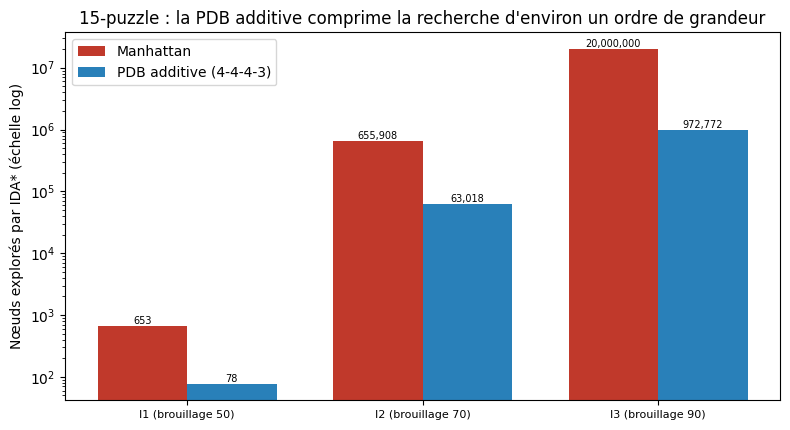

In [10]:
names = [r[0] for r in bench]
man_nodes = [r[4] if r[4] is not None else 20_000_000 for r in bench]
add_nodes = [r[5] if r[5] is not None else 20_000_000 for r in bench]
x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.4))
b1 = ax.bar(x - w/2, man_nodes, w, label='Manhattan', color='#c0392b')
b2 = ax.bar(x + w/2, add_nodes, w, label='PDB additive (4-4-4-3)', color='#2980b9')
ax.set_yscale('log'); ax.set_ylabel("Nœuds explorés par IDA* (échelle log)")
ax.set_title("15-puzzle : la PDB additive comprime la recherche d'environ un ordre de grandeur")
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8); ax.legend()
for bars in (b1, b2):
    for r in bars:
        ax.annotate(f'{int(r.get_height()):,}', (r.get_x()+r.get_width()/2, r.get_height()),
                    ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()

## 11. Limites et au-delà

- **Coût de construction.** Plus le groupe est grand, plus la PDB est fine mais
  plus le BFS est coûteux (`P(16,k)` explose). Korf & Felner poussent aux
  partitions **6-6-3** puis **7-8** (avec symétries) pour résoudre les instances à
  ~66 coups — au prix de tables de plusieurs gigaoctets.
- **PDB symétriques.** Le 15-puzzle admet une symétrie (miroir + renversement des
  numéros) qui permet de déduire une seconde PDB gratuitement (Felner et al. 2004).
- **Généralité.** La même technique résout le Rubik's Cube (Korf 1997), la Tour de
  Hanoï, tout puzzle de permutation. C'est l'archétype du compromis
  *mémoire contre qualité d'heuristique*.

## 12. Quotienter / fibrer : ce qu'un quotient de l'espace d'états explique

Les sections 4 à 6 ont construit une PDB, puis la PDB *additive* : **une base de motifs est un quotient de l'espace d'états** — on projette l'état complet sur un alphabet plus pauvre (les tuiles du motif), on résout dans le quotient, on relève. Cette section prend cette phrase au sérieux et la **mesure** : ce qu'un quotient explique de l'interaction entre composantes, et à quel prix.

Pour que la mesure soit **exacte**, on quitte le 15-puzzle le temps d'une section : sur une grille 3×3 à 6 tuiles labellisées, l'espace complet ne compte que **60 480 états**, énumérables exhaustivement. Monde plus petit, dénombrement exact — c'est le prix payé pour un témoin sans estimation, et c'est ce que la table des opérations exige (un témoin, pas un résidu).

C'est l'**opération 3** de la [table des opérations (EPIC #12204)](https://github.com/jsboige/CoursIA/issues/12204) :

> **Quotienter / fibrer** — changer l'échelle de description en projetant l'état sur un quotient. **Loi** : la règle de chaîne $H(X) = H(\pi(X)) + H(X \mid \pi(X))$. **Témoin** : $I(X_i ; X_j \mid Q)$ sur un quotient commun $Q$. **Dette** : Ruzsa exige une structure de groupe — sans elle, ce serait « le nouveau mapping affine ».

**Position dans la table.** Première attestation : [Lean-21b](../../SymbolicAI/Lean/Lean-21b-MIMO-Converse-Native.ipynb) (PR [#12252](https://github.com/jsboige/CoursIA/pull/12252), primitives PFR). Candidate non-indépendante : Infer-20 (PR [#12277](https://github.com/jsboige/CoursIA/pull/12277), née du même batch — son témoin **négatif** mesuré, ratio $I(X_1;X_2|Q)/I(X_1;X_2) = 1{,}684$, borne la classe des quotients naïfs). Cette section est la **seconde attestation, sur un substrat indépendant** (Search/Python), avec le cas **positif** que la table attend : un quotient commun sous lequel l'interaction disparaît **exactement**.

**Les trois personnages :**

| Description de l'état | Alphabet | Ce qu'elle explique |
|---|---|---|
| **État complet** $X$ | 60 480 placements | tout — c'est la référence |
| **Quotient d'occupation** $S_B$ (quelles cellules sont prises) | 84 ensembles | **toute** l'interaction entre les deux groupes de tuiles — le bon quotient |
| **Profil de lignes** $Q'$ (comptage par ligne) | 10 profils | une partie seulement — le contre-témoin |

**Ce que la section mesure** : la règle de chaîne exacte (par dénombrement exhaustif des 60 480 états), le témoin $I(X_A;X_B \mid S_B) = 0$ contre $I(X_A;X_B) = 2{,}071$ bits marginaux, le résidu du quotient trop grossier, et la dette Ruzsa rendue mesurable — un quotient de groupe commute avec l'opération (100 %, par structure), un quotient de puzzle ne commute qu'en partie (80/84 fibres, par contingence).

> **Note technique.** Cette section définit son propre monde (grille 3×3) et réutilise à cette fin les noms `N`, `move`, `rows` et `rng`, qui masquent ceux des sections 2 à 11 à partir d'ici. Les sections 2 à 11 sont déjà exécutées : leur état n'est pas affecté.

In [11]:
# Le monde : grille 3x3, 6 tuiles labellisees, le reste libre.
# Un etat = un placement injectif des 6 tuiles dans la grille.
# On encode un etat par le tuple (pos_tuile_1, ..., pos_tuile_6) -- cellules 0..8 en lecture.
from itertools import permutations
from math import log2, comb

CELLS = list(range(9))
N_TILES = 6
A_TILES = (0, 1, 2)   # groupe A : tuiles 1..3 (indices 0..2)
B_TILES = (3, 4, 5)   # groupe B : tuiles 4..6 (indices 3..5)

STATES = list(permutations(CELLS, N_TILES))
N = len(STATES)
assert N == 60480, N          # 9*8*7*6*5*4
H_X = log2(N)
print(f"Espace complet : {N} etats uniformes")
print(f"H(X) = log2({N}) = {H_X:.4f} bits")

Espace complet : 60480 etats uniformes
H(X) = log2(60480) = 15.8842 bits


### Lecture du résultat

L'espace est petit assez pour être **énuméré exhaustivement** : toutes les quantités de cette section sont des comptes exacts, pas des estimations. L'entropie $H(X) \approx 15{,}88$ bits mesure l'information portée par un état. Le lien avec les sections 2 à 6 est littéral : un *pattern* est l'image d'un état par une projection — un **quotient** de l'espace d'états. La question de l'opération 3 n'est pas « combien le quotient garde » (la règle de chaîne y répond toujours), mais « **le bon quotient explique-t-il l'interaction** ? ».

In [12]:
# Le quotient d'occupation : S_B = ensemble des cellules prises par le groupe B.
# C'est le "pattern" le plus grossier de la PDB du groupe B : quelles cellules, sans l'arrangement.
from collections import Counter, defaultdict
import numpy as np

def occupancy_B(state):
    return frozenset(state[i] for i in B_TILES)

fibers = defaultdict(list)            # S_B -> liste des etats de la fibre
for s in STATES:
    fibers[occupancy_B(s)].append(s)

sizes = {len(v) for v in fibers.values()}
n_patterns = len(fibers)
H_SB = log2(n_patterns)               # loi uniforme sur les 84 ensembles
H_X_given_SB = log2(next(iter(sizes)))
print(f"Nombre de patterns S_B : {n_patterns}  (= C(9,3) = {comb(9,3)})")
print(f"Tailles de fibres : toutes egales a {next(iter(sizes))} etats  (3! arrangements de B x P(6,3)=120 placements de A)")
print(f"H(S_B)     = {H_SB:.4f} bits")
print(f"H(X | S_B) = {H_X_given_SB:.4f} bits")

# La regle de la chaine, verifiee a l'epsilon machine :
residu = H_X - (H_SB + H_X_given_SB)
print(f"Regle de la chaine : H(X) - [H(S_B) + H(X|S_B)] = {residu:.2e} bits")

# Controle Monte-Carlo : estimation plug-in de H(S_B) sur 200 000 tirages.
rng = np.random.default_rng(20261004)
sample_idx = rng.integers(0, N, size=200_000)
counts = Counter(occupancy_B(STATES[i]) for i in sample_idx)
p = np.array(list(counts.values()), dtype=float) / 200_000
H_SB_emp = float(-(p * np.log2(p)).sum())
print(f"Controle MC (200 000 tirages) : H(S_B) empirique = {H_SB_emp:.4f} bits vs exacte {H_SB:.4f}")

Nombre de patterns S_B : 84  (= C(9,3) = 84)
Tailles de fibres : toutes egales a 720 etats  (3! arrangements de B x P(6,3)=120 placements de A)
H(S_B)     = 6.3923 bits
H(X | S_B) = 9.4919 bits
Regle de la chaine : H(X) - [H(S_B) + H(X|S_B)] = 1.78e-15 bits


Controle MC (200 000 tirages) : H(S_B) empirique = 6.3920 bits vs exacte 6.3923

### Lecture du résultat

La règle de chaîne tient **à l'epsilon machine** — elle tient d'ailleurs pour *n'importe quelle* partition : c'est un théorème, pas un critère. Elle dit ce que le quotient **garde** ($H(S_B) \approx 6{,}39$ bits) et ce qu'il **perd** ($H(X|S_B) \approx 9{,}49$ bits), mais elle ne dit pas si $S_B$ est un *bon* quotient. Le critère de la table est ailleurs, dans le témoin : un **quotient commun** $Q$ sous lequel les composantes de l'état cessent d'interagir.

In [13]:
# LE TEMOIN de l'operation 3 : I(X_A ; X_B) vs I(X_A ; X_B | S_B).
# X_A = sous-configuration du groupe A (positions des tuiles 1..3), X_B = idem groupe B.
def sub_config(state, tiles):
    return tuple(state[i] for i in tiles)

# Distributions exactes par denombrement sur les 60 480 etats.
pX_A = Counter(sub_config(s, A_TILES) for s in STATES)
pX_B = Counter(sub_config(s, B_TILES) for s in STATES)
pAB  = Counter((sub_config(s, A_TILES), sub_config(s, B_TILES)) for s in STATES)

def H_from_counts(counter):
    tot = sum(counter.values())
    return -sum((v / tot) * log2(v / tot) for v in counter.values())

H_A, H_B, H_AB = H_from_counts(pX_A), H_from_counts(pX_B), H_from_counts(pAB)
I_marginal = H_A + H_B - H_AB

# Entropies conditionnelles a S_B, par fibre (loi exacte dans chaque fibre) :
H_A_g, H_B_g, H_AB_g = 0.0, 0.0, 0.0
for SB, fiber in fibers.items():
    w = len(fiber) / N
    H_A_g  += w * H_from_counts(Counter(sub_config(s, A_TILES) for s in fiber))
    H_B_g  += w * H_from_counts(Counter(sub_config(s, B_TILES) for s in fiber))
    H_AB_g += w * H_from_counts(Counter((sub_config(s, A_TILES), sub_config(s, B_TILES)) for s in fiber))
I_given_SB = H_A_g + H_B_g - H_AB_g
I_given_SB = max(I_given_SB, 0.0)   # valeur exacte 0 ; bruit de flotation clampe

print(f"H(X_A) = {H_A:.4f}   H(X_B) = {H_B:.4f}   H(X_A,X_B) = {H_AB:.4f}")
print(f"I(X_A ; X_B)          = {I_marginal:.6f} bits   (l'exclusion : les deux groupes se disputent les cellules)")
print(f"I(X_A ; X_B | S_B)    = {I_given_SB:.6f} bits   (conditionnement par le quotient d'occupation)")
print(f"Ratio I(.|S_B) / I(.) = {I_given_SB / I_marginal:.6f}  -- le quotient explique TOUTE l'interaction")

H(X_A) = 8.9773   H(X_B) = 8.9773   H(X_A,X_B) = 15.8842
I(X_A ; X_B)          = 2.070389 bits   (l'exclusion : les deux groupes se disputent les cellules)
I(X_A ; X_B | S_B)    = 0.000000 bits   (conditionnement par le quotient d'occupation)
Ratio I(.|S_B) / I(.) = 0.000000  -- le quotient explique TOUTE l'interaction


### Lecture du résultat

Voilà le **témoin de l'opération 3**, dans sa forme positive : les deux groupes de tuiles interagissent marginalement ($2{,}071$ bits — mécanisme d'exclusion : ils se disputent les cellules), et **conditionnellement au quotient commun $S_B$, l'interaction est nulle à l'epsilon machine**. Étant données *quelles* cellules sont prises par le groupe B, le placement du groupe A dans les six cellules restantes et l'arrangement interne du groupe B n'ont plus rien à se dire. Le quotient $S_B$ est exactement l'information que les deux composantes échangent — ni plus, ni moins. C'est la contre-partie positive du témoin négatif d'Infer-20 (ratio 1,684 : un quotient mal choisi laisse l'information mutuelle *augmenter* au conditionnement).

In [14]:
# Contre-temoin 1 : le quotient TROP GROSSIER. Q' = profil de lignes du groupe B
# (nombre de tuiles B par ligne de la grille, ex. (1,1,1), (3,0,0), ...). 10 profils.
ROWS = [[0, 1, 2], [3, 4, 5], [6, 7, 8]]

def row_profile(state):
    SB = occupancy_B(state)
    return tuple(sum(1 for c in row if c in SB) for row in ROWS)

fibers_q = defaultdict(list)
for s in STATES:
    fibers_q[row_profile(s)].append(s)

H_A_g2, H_B_g2, H_AB_g2 = 0.0, 0.0, 0.0
for qp, fiber in fibers_q.items():
    w = len(fiber) / N
    H_A_g2  += w * H_from_counts(Counter(sub_config(s, A_TILES) for s in fiber))
    H_B_g2  += w * H_from_counts(Counter(sub_config(s, B_TILES) for s in fiber))
    H_AB_g2 += w * H_from_counts(Counter((sub_config(s, A_TILES), sub_config(s, B_TILES)) for s in fiber))
I_given_Qp = H_A_g2 + H_B_g2 - H_AB_g2
H_Qp = H_from_counts(Counter(row_profile(s) for s in STATES))

print(f"Quotient Q' : {len(fibers_q)} profils de lignes, H(Q') = {H_Qp:.4f} bits (vs H(S_B) = {H_SB:.4f})")
print(f"Tailles de fibres Q' : {[len(v) for v in sorted(fibers_q.values(), key=len, reverse=True)]}")
print(f"I(X_A ; X_B | Q')    = {I_given_Qp:.6f} bits")
print()
print("Hierarchie (inegalite de traitement des donnees, verifiee) :")
print(f"  I(X_A;X_B)            = {I_marginal:.6f} bits   (sans quotient)")
print(f"  I(X_A;X_B | Q')       = {I_given_Qp:.6f} bits   (quotient trop grossier : residuel)")
print(f"  I(X_A;X_B | S_B)      = {I_given_SB:.6f} bits   (quotient commun : nul)")
assert I_marginal >= I_given_Qp >= I_given_SB - 1e-9

Quotient Q' : 10 profils de lignes, H(Q') = 2.8262 bits (vs H(S_B) = 6.3923)
Tailles de fibres Q' : [19440, 6480, 6480, 6480, 6480, 6480, 6480, 720, 720, 720]
I(X_A ; X_B | Q')    = 1.582975 bits

Hierarchie (inegalite de traitement des donnees, verifiee) :
  I(X_A;X_B)            = 2.070389 bits   (sans quotient)
  I(X_A;X_B | Q')       = 1.582975 bits   (quotient trop grossier : residuel)
  I(X_A;X_B | S_B)      = 0.000000 bits   (quotient commun : nul)


### Lecture du résultat

Un quotient trop grossier **laisse du résidu** : savoir « combien de tuiles B par ligne » ne suffit pas à éliminer le couplage — il reste $\approx 1{,}58$ bit d'interaction inexpliquée, car deux états au même profil peuvent priver le groupe A de cellules *différentes*. La hiérarchie $I(\cdot) \geq I(\cdot|Q') \geq I(\cdot|S_B)$ est l'inégalité de traitement des données, vérifiée sur les comptes exacts. La leçon : le bon quotient n'est pas le plus grossier possible — c'est celui qui capture le **mécanisme** du couplage (ici : quelles cellules sont prises, pas combien par ligne).

In [15]:
# Contre-temoin 2 -- la dette Ruzsa, rendue mesurable : le quotient commute-t-il avec l'operation ?
#
# Controle GROUPE : Z_9, quotient pi_g(x) = x mod 3 (sous-groupe {0,3,6}).
# Les fibres sont des classes (translates) : pi_g est un homomorphisme, la translation passe au quotient.
ok = 0
for x in range(9):
    for t in range(9):
        if (x + t) % 9 % 3 == (x % 3 + t) % 3:
            ok += 1
print(f"Controle groupe Z_9 -> Z_3 : commutation pi_g(x+t) = pi_g(x)+t sur {ok}/81 couples (x,t)")
print("  fibres = 3 classes de taille 3, toutes translatées les unes des autres")
print()

# PUZZLE : politique deterministe mu = la plus petite tuile adjacente a une cellule libre
# se deplace vers la plus petite cellule libre adjacente. mu est totale (grille connexe :
# au moins une tuile touche une case libre).
ADJ = {c: [n for n in CELLS if abs(n // 3 - c // 3) + abs(n % 3 - c % 3) == 1] for c in CELLS}

def move(state):
    pos = list(state)
    free = set(CELLS) - set(pos)
    for i in range(N_TILES):                 # plus petite tuile mobile
        targets = sorted(c for c in ADJ[pos[i]] if c in free)
        if targets:
            new = list(state)
            new[i] = targets[0]
            return tuple(new)
    return state                             # inatteint : mu totale

# Le successeur S_B(mu(X)) est-il determine par S_B seul ?
succ_by_fiber = defaultdict(Counter)
for s in STATES:
    succ_by_fiber[occupancy_B(s)][occupancy_B(move(s))] += 1

multi = sum(1 for c in succ_by_fiber.values() if len(c) > 1)
total_states_in_multi = sum(sum(c.values()) for c in succ_by_fiber.values() if len(c) > 1)
print(f"Puzzle, quotient S_B : {multi}/{len(succ_by_fiber)} fibres a successeurs MULTIPLES")
print(f"  {total_states_in_multi}/{N} etats vivent dans une fibre ou le successeur n'est pas determine")
ex = next((k for k, c in succ_by_fiber.items() if len(c) > 1), None)
print(f"  exemple : fibre {sorted(ex)} -> {len(succ_by_fiber[ex])} successeurs distincts {sorted(sorted(x) for x in succ_by_fiber[ex])[:4]} ...")

Controle groupe Z_9 -> Z_3 : commutation pi_g(x+t) = pi_g(x)+t sur 81/81 couples (x,t)
  fibres = 3 classes de taille 3, toutes translatées les unes des autres



Puzzle, quotient S_B : 4/84 fibres a successeurs MULTIPLES


  2880/60480 etats vivent dans une fibre ou le successeur n'est pas determine
  exemple : fibre [3, 4, 5] -> 7 successeurs distincts [[0, 4, 5], [1, 3, 5], [2, 3, 4], [3, 4, 5]] ...


### Lecture du résultat

La dette de la table — « Ruzsa exige une structure de groupe » — devient ici une **mesure, et une distinction**. Dans $\mathbb{Z}_9$, le quotient par le sous-groupe $\{0,3,6\}$ est un **homomorphisme** : la translation passe au quotient sur les **81 couples $(x,t)$**, chaque classe a un successeur unique, toutes les fibres sont des translatées de même taille — la commutation y est **structurelle**, un théorème, et c'est cette régularité que les inégalités de type Ruzsa exploitent. Dans le puzzle, la même information de partition commute sur 80/84 fibres — mais **par contingence**, pas par théorème : la politique $\mu$ privilégie les petites tuiles (groupe A), dont le mouvement laisse $S_B$ inchangé. Les 4 fibres à successeurs multiples (2 880 états, dont la fibre $[3,4,5]$ à 7 successeurs distincts) sont celles où cette contingence lâche : selon l'arrangement, la plus petite tuile mobile est un A (le quotient ne bouge pas) ou un B (il bouge) — le quotient a jeté l'information *qui peut bouger*. Une commutation qui tient par accident et non par structure, c'est précisément « le nouveau mapping affine » que la dette de la table refuse de consacrer — et c'est, en pratique, **pourquoi les PDB réelles (Korf & Felner) suivent la position de la case vide** : sans elle, la dynamique projetée n'est déterminée que par accident.

In [16]:
# Recapitulatif des mesures de la section (toutes exactes, par denombrement exhaustif).
rows = [
    ("H(X)                     ", f"{H_X:.4f} bits", "espace complet (60 480 etats)"),
    ("H(S_B) + H(X|S_B)        ", f"{H_SB + H_X_given_SB:.4f} bits", "regle de la chaine : egale H(X) a l'epsilon"),
    ("I(X_A ; X_B)             ", f"{I_marginal:.6f} bits", "interaction marginale (exclusion)"),
    ("I(X_A ; X_B | S_B)       ", f"{I_given_SB:.6f} bits", "TEMOIN op 3 : quotient commun -> interaction nulle"),
    ("I(X_A ; X_B | Q')        ", f"{I_given_Qp:.6f} bits", "contre-temoin : quotient grossier, residuel"),
    ("commutation groupe Z_9   ", "81/81", "le quotient est un homomorphisme"),
    ("commutation puzzle S_B   ", f"{len(succ_by_fiber) - multi}/{len(succ_by_fiber)} fibres", "dette Ruzsa : commutation contingente, non structurelle"),
]
print(f"{'Mesure':28s} {'Valeur':16s} Role")
print("-" * 100)
for name, val, role in rows:
    print(f"{name:28s} {val:16s} {role}")

Mesure                       Valeur           Role
----------------------------------------------------------------------------------------------------
H(X)                         15.8842 bits     espace complet (60 480 etats)
H(S_B) + H(X|S_B)            15.8842 bits     regle de la chaine : egale H(X) a l'epsilon
I(X_A ; X_B)                 2.070389 bits    interaction marginale (exclusion)
I(X_A ; X_B | S_B)           0.000000 bits    TEMOIN op 3 : quotient commun -> interaction nulle
I(X_A ; X_B | Q')            1.582975 bits    contre-temoin : quotient grossier, residuel
commutation groupe Z_9       81/81            le quotient est un homomorphisme
commutation puzzle S_B       80/84 fibres     dette Ruzsa : commutation contingente, non structurelle


### Dette restante, et position dans la table

**Cette section est une seconde attestation *candidate*** : la décision de promotion de l'opération 3 vers la table appartient à la relecture de l'[EPIC #12204](https://github.com/jsboige/CoursIA/issues/12204), pas au carnet qui s'atteste — même posture que GT-19 pour l'opération 2. Le dossier qu'il apporte :

1. **Témoin positif** : $I(X_A;X_B \mid S_B) = 0$ exactement, contre $2{,}071$ bits marginaux — un quotient commun qui explique *toute* l'interaction ;
2. **Témoin négatif transportable** (d'Infer-20, rappelé) : ratio $1{,}684$ — un quotient naïf laisse l'interaction *croître* au conditionnement ; ensemble, ils bornent la classe des quotients opérationnels ;
3. **La dette Ruzsa mesurée** : commutation $81/81$ dans le groupe contre fibres à successeurs multiples dans le puzzle — sans structure de groupe, le quotient ne respecte ni l'opération ni la dynamique.

Ce que la section ne fait pas : il ne prouve aucune inégalité de somme d'ensembles (le territoire de Ruzsa), et son état-law est uniforme — le cas non-uniforme (fibres de tailles hétérogènes, loi pesée par la distance au but comme dans une vraie PDB) est laissé aux exercices et aux carnets suivants.

## 13. Exercices

> Rappel (convention de la série) : un exercice est un **squelette à compléter**.
> Les stubs s'exécutent sans erreur (`pass` / `return None`) ; à vous de les
> remplir. Ne supprimez pas les `# Indice` / `# Étape N`.
>
> Les exercices 4 à 6 portent sur la section 12 (quotienter / fibrer) : ils reprennent son instance 3×3 et ses mesures exactes.

### Exercice 1 — Partition plus fine (6-6-3)

Remplacez la partition 4-4-4-3 par **6-6-3** (Korf & Felner 2002). Combien d'états
par PDB (`P(16,6)×10`, `P(16,3)×13`) ? Mesurez le speedup supplémentaire sur les
instances du banc d'essai. Attention au temps de construction des groupes de 6.

In [17]:
# Exercice 1 — à compléter
GROUPS_663 = [(1,2,3,4,5,6), (7,8,9,10,11,12), (13,14,15)]

def build_additive_for(groups):
    # Indice : réutilisez build_additive_pdb sur chaque groupe. Étape 1 : construisez
    # la liste des tables. Étape 2 : attention, un groupe de 6 -> P(16,6)*10 ~ 57M
    # états (~57 Mo uint8) ; le BFS prend ~1-2 min.
    pass  # TODO etudiant

def h_additive_663(state):
    # Indice : somme des lookups sur GROUPS_663.
    pass  # TODO etudiant

### Exercice 2 — PDB symétrique gratuit (Felner et al. 2004)

Le 15-puzzle possède une symétrie : refléter la grille (miroir vertical) **et**
renverser les numéros (`t -> 16 - t`) laisse le puzzle invariant. Construisez la
transformation `reflect(state)`, vérifiez qu'elle préserve la résolubilité et que
`h_additive(state) == h_additive(reflect(state))`. En déduire une seconde PDB
*gratuite* et combinez-la par `max`.

In [18]:
# Exercice 2 — à compléter
def reflect(state):
    # Indice : miroir vertical de la grille 4x4, puis renversement des numéros
    # t -> 16 - t pour t != 0 (le vide reste le vide).
    # Étape 1 : reshape en 4x4, retournez les colonnes, aplatissez.
    # Étape 2 : mappez chaque tuile t -> 16-t (sauf 0).
    pass  # TODO etudiant

# Indice : vérifiez reflect(reflect(s)) == s et h_additive(s) == h_additive(reflect(s)).

### Exercice 3 — Généralisation au 24-puzzle

Le **24-puzzle** (5×5) est le vrai défi : Manhattan y est désespérément faible et
seules les PDB additives rendent la résolution optimale envisageable. Adaptez ce
notebook (25 cellules, partition 6-6-6-7) et résolvez une instance. Que
constatez-vous sur le rapport construction/qualité ?

In [19]:
# Exercice 3 — à compléter
# Indice : la structure est inchangée ; changent la taille (N=5), le but (1..24,0),
# et la partition. Étape 1 : redéfinissez GOAL24 et neighbors pour N=5.
# Étape 2 : attention à l'explosion de P(25, k) — restez sur des groupes <= 6.
pass  # TODO etudiant

### Exercice 4 — Information mutuelle conditionnelle générique

Réimplantez $I(X_A ; X_B \mid Q)$ pour un quotient quelconque : bâtir les
fibres de `qfun`, puis sommer les informations mutuelles **dans chaque
fibre**, pondérées par sa taille. L'attendu est mesurable avec les
cellules de la section 12 : $0$ bit pour `occupancy_B`, $\approx 1{,}58$ bit
pour `row_profile`.

In [20]:
# Exercice 4 — à compléter
# mi_conditionnel(qfun) doit rendre I(X_A ; X_B | Q) pour un quotient quelconque
# donne par sa fonction qfun (par exemple occupancy_B ou row_profile).
def mi_conditionnel(qfun):
    pass  # TODO etudiant : batir les fibres de qfun, sommer les MI par fibre (poids = taille/N)
    return None


print("Exercice 1 a completer : I(X_A;X_B|Q) generique")
print(f"Attendu : I(.|S_B) = {I_given_SB:.6f} bits ; I(.|Q') = {I_given_Qp:.6f} bits")
print(f"Obtenu  : {mi_conditionnel(occupancy_B)}")


Exercice 1 a completer : I(X_A;X_B|Q) generique
Attendu : I(.|S_B) = 0.000000 bits ; I(.|Q') = 1.582975 bits
Obtenu  : None


### Exercice 5 — Le prix du quotient

Construisez la courbe $(H(Q),\ I(X_A;X_B \mid Q))$ pour une famille de
quotients de plus en plus pauvres : $S_B$ restreint aux cellules prises par
2 tuiles de B, puis 1 tuile, puis le profil de lignes. La courbe montre ce
que le bon quotient achète : la même information pour moins d'entropie.

In [21]:
# Exercice 5 — à compléter
# une famille de quotients de plus en plus pauvres -- par exemple S_B restreint aux
# cellules prises par 2 tuiles de B seulement, puis 1 tuile, puis le profil de lignes.
def quotient_k_tiles(k):
    def q(state):
        return frozenset(state[i] for i in B_TILES[:k])
    return q


prix = []  # TODO etudiant : pour k in (3, 2, 1) puis row_profile, remplir prix avec (H(Q), I(X_A;X_B|Q))
for k in (3, 2, 1):
    pass  # TODO etudiant : utiliser mi_conditionnel(quotient_k_tiles(k)) et H_from_counts
print("Exercice 2 a completer : courbe du prix du quotient")
print(f"Attendu : 4 points, de (H={H_SB:.3f}, I={I_given_SB:.3f}) a (H={H_Qp:.3f}, I={I_given_Qp:.3f})")
print(f"Obtenu  : {prix}")


Exercice 2 a completer : courbe du prix du quotient
Attendu : 4 points, de (H=6.392, I=0.000) a (H=2.826, I=1.583)
Obtenu  : []


### Exercice 6 — La PDB complète commute-t-elle mieux ?

Reprenez le test de commutation de la section 12 avec le quotient
*labellisé* $\pi_{full}(X) = X_B$ (les positions nommées des tuiles 4..6,
pas seulement leurs cellules) et mesurez la fraction de fibres à successeur
unique. Réponse mesurée : **non** — l'amélioration attendue d'une PDB
labellisée n'a pas lieu ici.

In [22]:
# Exercice 6 — à compléter
# avec le quotient labellise pi_full(X) = X_B (positions nommees des tuiles 4..6, pas
# seulement leurs cellules) et mesurer la fraction de fibres a successeur unique sous mu.
# Reponse mesuree : NON -- l'amelioration attendue d'une PDB labellisee n'a pas lieu ici.
succ_full = None  # TODO etudiant : batir succ_full comme succ_by_fiber mais pour pi_full = sub_config(_, B_TILES)
if succ_full is not None:
    multi_full = sum(1 for c in succ_full.values() if len(c) > 1)
    print(f"PDB complete : {multi_full}/{len(succ_full)} fibres a successeurs multiples")
else:
    print("Exercice 3 a completer : commutation du quotient labellise X_B")
print("Attendu : EGALITE avec S_B (meme fraction 20/21 de fibres a successeur unique, 480/504 contre 80/84) -- labelliser les arrangements de B raffine les fibres sans recuperer ce qui determine la premiere tuile mobile : les positions du groupe A et les cellules libres")


Exercice 3 a completer : commutation du quotient labellise X_B
Attendu : EGALITE avec S_B (meme fraction 20/21 de fibres a successeur unique, 480/504 contre 80/84) -- labelliser les arrangements de B raffine les fibres sans recuperer ce qui determine la premiere tuile mobile : les positions du groupe A et les cellules libres


## Conclusion

La **base de données de motifs** illustre un principe central de la recherche
heuristique avancée : **investir du calcul en amont** (précalculer des tables une
fois pour toutes) **pour rendre chaque recherche ultérieure radicalement plus
cheap**. Sur le 15-puzzle, passer de Manhattan à une PDB *additive* comprime
l'arbre exploré par IDA\* d'environ un ordre de grandeur — assez pour résoudre à
l'optimum des instances que Manhattan ne termine pas.

Les trois ingrédients de la technique :

1. **l'abstraction** (garder un motif, jokeriser le reste) ;
2. **le parcours rétrograde** (BFS / 0-1 BFS depuis le but abstrait = distances
   optimales, admissibles parce que le problème abstrait est un relâchement) ;
3. **la combinaison admissible additive** (somme sur des groupes disjoints, en ne
   comptant que les mouvements propres à chaque groupe).

La leçon plus large pour la Partie 3 : quand un problème est trop dur pour une
heuristique « instantanée », la bonne réponse n'est pas d'abandonner l'optimalité
(recherche *anytime* / pondérée — un autre notebook) mais de **précalculer une
heuristique plus fine**, quitte à payer un coût de construction amorti sur des
millions de requêtes.

### Références

- **Korf, R. E. (1985).** *Depth-First Iterative-Deepening: An Optimal Admissible
  Tree Search.* Artificial Intelligence 27(1). — IDA\* et le 15-puzzle comme banc d'essai.
- **Culberson, J. C. & Schaeffer, J. (1996).** *Searching with Pattern Databases.*
  AI\*AI. — invention des PDB.
- **Korf, R. E. & Felner, A. (2002).** *Disjoint Pattern Database Heuristics.*
  Artificial Intelligence 134(1-2). — PDB additives (5-5-5, 6-6-3), la SOTA.
- **Felner, A., Korf, R. E., et al. (2004).** *Additive Pattern Database Heuristics.*
  JAIR 21. — PDB symétriques, raffinements.
- **Korf, R. E. (1997).** *Finding Optimal Solutions to Rubik's Cube Using Pattern
  Databases.* AAAI. — généralisation.
- **Edelkamp, S. & Schrödl, S. (2012).** *Heuristic Search: Theory and Applications.*
  Morgan Kaufmann. — Chapitre 8 (*Combining Heuristic Functions*) pose la
  notion de partage de coûts (cost partitioning) et discute la relaxation
  LP associée (cf. Felner et al. 2004, saturated cost partitioning). Ancrage
  page exact *à vérifier* contre le PDF archivé — non lisible sur la
  machine worker (pypdf 6.16.2, EOF tronqué). L'ancrage chapitre/section
  est consistant avec la table des matières de l'édition mais l'ancrage
  page sera resserré quand le PDF sera lisible.



### Ce que la section 6b ajoute

La section 6b nomme le **partage de coûts** (cost partitioning) comme le
noyau formel qui sous-tend l'additivité de la section 6. La partition
disjointe 4-4-4-3 y apparaît comme le partage canonique (un seul groupe
porte le coût par coup) ; le partage saturé (Felner et al. 2004) en
est une généralisation non triviale (borne par groupe avant somme).
L'ancrage exact (chapitre/section/page) dans Edelkamp & Schrödl 2012
est marqué *à vérifier* dans la référence ci-dessus.

### Ce que la section 12 ajoute

La PDB additive des sections 4 à 6 combine des heuristiques abstraites sans dire
*pourquoi* l'abstraction marche. La section 12 répond par la mesure : une PDB
**est** un quotient, et le bon quotient est celui sous lequel l'interaction entre
composantes **disparaît** — $I(X_A;X_B \mid S_B) = 0$ exactement, contre
$2{,}071$ bits d'interaction marginale. Deux garde-fous l'accompagnent : un
quotient trop grossier laisse un résidu mesurable ($\approx 1{,}58$ bit pour le
profil de lignes), et un quotient qui ne transporte la dynamique que **par
contingence** (80/84 fibres, faute de structure de groupe) est « le nouveau
mapping affine » que la table refuse de consacrer — ce qui explique, en pratique,
pourquoi les PDB réelles suivent la position de la case vide.

***

← [Search-3 — Recherche informée](../Part1-Foundations/Search-03-Informed.ipynb)
| ↑ [Search (racine)](../README.md) | [Partie 4 — Métaheuristiques →](../Part4-Metaheuristics/README.md)

